# Definición de modelo e implementación
Generación de caso piloto de PINN en MLP sencilla, y posteriormente aplicación en esquema

## Modelo tradicional

### Definición del modelo

0) Importe de modulos

In [2]:
import torch
import math
import time

import torch.nn             as nn
import torch.optim          as optim
import numpy                as np
import matplotlib.pyplot    as plt

1) Operador de la ecuación de Schrodinger 1D (iría en nn/pde.py)

In [3]:
def schrodinger_operator(model, t, x, potential_fn=0, mass=1.0, hbar=1.0):
    """
    Residuos de: i*hbar*psi_t = -(hbar^2/(2m)) * psi_xx + V * psi
    model(t,x) -> [psi_r, psi_i]
    """
    t = t.requires_grad_(True)
    x = x.requires_grad_(True)

    psi = model(torch.cat((t, x), dim=1))
    psi_r = psi[:, 0:1]
    psi_i = psi[:, 1:2]

    # Derivadas temporales
    psi_t_r = torch.autograd.grad(psi_r, t, torch.ones_like(psi_r), create_graph=True)[0]
    psi_t_i = torch.autograd.grad(psi_i, t, torch.ones_like(psi_i), create_graph=True)[0]

    # Derivadas espaciales segunda
    psi_x_r  = torch.autograd.grad(psi_r, x, torch.ones_like(psi_r), create_graph=True)[0]
    psi_x_i  = torch.autograd.grad(psi_i, x, torch.ones_like(psi_i), create_graph=True)[0]
    psi_xx_r = torch.autograd.grad(psi_x_r, x, torch.ones_like(psi_x_r), create_graph=True)[0]
    psi_xx_i = torch.autograd.grad(psi_x_i, x, torch.ones_like(psi_x_i), create_graph=True)[0]

    V = potential_fn(t, x) if potential_fn is not None else torch.zeros_like(psi_r)
    coef = (hbar**2) / (2.0 * mass)

    residual_r = -hbar * psi_t_i + coef * psi_xx_r - V * psi_r
    residual_i =  hbar * psi_t_r + coef * psi_xx_i - V * psi_i

    return psi_r, psi_i, residual_r, residual_i


2) Modelo "dummy" analítico: onda plana

In [3]:
class PlaneWaveModel(nn.Module):
    """
    Produce psi_r, psi_i de una onda plana: exp(i*(k*x - omega*t)).
    omega debe satisfacer: omega = hbar*k^2/(2*m) + V0/hbar si V=V0 (cte).
    """
    def __init__(self, k: float, mass: float = 1.0, hbar: float = 1.0, V0: float = 0.0):
        super().__init__()
        # Guardamos como tensores para que vivan en el mismo device/dtype que las entradas
        self.k   = torch.tensor(float(k))
        self.m   = torch.tensor(float(mass))
        self.h   = torch.tensor(float(hbar))
        self.V0  = torch.tensor(float(V0))
        # Relación de dispersión (analítica)
        self.omega = self.h * (self.k**2) / (2.0 * self.m) + self.V0 / self.h

    def forward(self, tx: torch.Tensor) -> torch.Tensor:
        # tx: (N,2) -> t=col0, x=col1
        t = tx[:, :1]
        x = tx[:, 1:2]

        # Asegurar que k,omega estén en el mismo device/dtype que t/x
        k = self.k.to(t.device, dtype=t.dtype)
        omega = self.omega.to(t.device, dtype=t.dtype)

        phi = k * x - omega * t
        psi_r = torch.cos(phi)
        psi_i = torch.sin(phi)
        return torch.cat([psi_r, psi_i], dim=1)

3) Potenciales para test

In [4]:
def V_zero(t, x):
    return torch.zeros_like(t)

def V_const_factory(V0: float):
    def V_const(t, x):
        return torch.full_like(t, fill_value=V0)
    return V_const

4) Rutina de prueba

In [5]:
@torch.no_grad()
def summary_stats(name, res_r, res_i):
    r = res_r.detach().abs()
    i = res_i.detach().abs()
    print(f"[{name}] MSE_r={res_r.pow(2).mean():.3e} | MSE_i={res_i.pow(2).mean():.3e}  "
          f"| max_r={r.max():.3e}  max_i={i.max():.3e}")

def run_tests(device=None, dtype=torch.float64):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device} | dtype: {dtype}")

    torch.manual_seed(0)

    # Malla de evaluación
    N = 4096
    t = torch.rand(N, 1, device=device, dtype=dtype) * 1.0      # t in [0,1]
    x = (torch.rand(N, 1, device=device, dtype=dtype) - 0.5) * 2.0 * torch.pi  # x in [-pi, pi]

    # --- Caso A: V=0, varios k ---
    for k in [0.5, 1.0, 2.5]:
        model = PlaneWaveModel(k=k, mass=1.0, hbar=1.0, V0=0.0).to(device)
        psi_r, psi_i, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_zero, mass=1.0, hbar=1.0)
        summary_stats(f"V=0  | k={k}", rR, rI)

    # Umbral esperado (float64): ~1e-10 a 1e-12; con float32: ~1e-6 a 1e-7
    # Puedes hacer asserts suaves:
    model = PlaneWaveModel(k=1.234, mass=1.0, hbar=1.0, V0=0.0).to(device)
    _, _, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_zero, mass=1.0, hbar=1.0)
    tol = 1e-9 if dtype == torch.float64 else 5e-6
    assert rR.pow(2).mean().item() < tol and rI.pow(2).mean().item() < tol, "Test V=0 no pasó el umbral."

    # --- Caso B: V = V0 constante (comprobar término de potencial) ---
    for V0 in [0.3, -0.7]:
        k = 1.1
        model = PlaneWaveModel(k=k, mass=1.0, hbar=1.0, V0=V0).to(device)
        V_fn = V_const_factory(V0)
        psi_r, psi_i, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_fn, mass=1.0, hbar=1.0)
        summary_stats(f"V=cte | V0={V0}", rR, rI)

    print("✔️ Todos los tests básicos ejecutados.")

In [6]:
run_tests()

Device: cpu | dtype: torch.float64
[V=0  | k=0.5] MSE_r=0.000e+00 | MSE_i=0.000e+00  | max_r=0.000e+00  max_i=0.000e+00
[V=0  | k=1.0] MSE_r=0.000e+00 | MSE_i=0.000e+00  | max_r=0.000e+00  max_i=0.000e+00
[V=0  | k=2.5] MSE_r=3.443e-32 | MSE_i=3.231e-32  | max_r=4.441e-16  max_i=4.441e-16
[V=cte | V0=0.3] MSE_r=1.187e-17 | MSE_i=1.087e-17  | max_r=4.768e-09  max_i=4.768e-09
[V=cte | V0=-0.7] MSE_r=1.220e-17 | MSE_i=1.054e-17  | max_r=4.768e-09  max_i=4.768e-09
✔️ Todos los tests básicos ejecutados.


### Generación de caso de estudio

1) Parámetros físicos y de dominio

In [5]:
# Input parameters: Iterable
L = 1.0        # dominio espacial [0, L]
T = 0.2        # tiempo final
hbar = 1.0
mass = 1.0
n_level = 1    # nivel del pozo (usaremos n=1)
omega  = 1.0

potential_fn = lambda x : 0.5 * mass * (omega**2) * (x**2)

2) Muestreo y entrenamiento

In [6]:
N_f = 100     # collocation (interior)
N_b = 100      # borde (x=0 y x=L)
N_0 = 100      # inicial (t=0)

EPOCHS = 10000   # aumenta si quieres más precisión
LR = 1e-3
PRINT_EVERY = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32  # mejor precisión para EDP de 2º orden
torch.set_default_dtype(DTYPE)
torch.manual_seed(0);

3) Operador de Schrödinger (iría en nn/pde.py)

In [74]:
def schrodinger_operator(model, t, x, potential_fn=0, mass=1.0, hbar=1.0):
    """
    Residuos de: i*hbar*psi_t = -(hbar^2/(2m)) * psi_xx + V * psi
    model(t,x) -> [psi_r, psi_i]
    """
    t = t.requires_grad_(True)
    x = x.requires_grad_(True)

    psi = model(torch.cat((t, x), dim=1))
    psi_r = psi[:, 0:1]
    psi_i = psi[:, 1:2]

    psi_t_r = torch.autograd.grad(psi_r, t, torch.ones_like(psi_r), create_graph=True)[0]
    psi_t_i = torch.autograd.grad(psi_i, t, torch.ones_like(psi_i), create_graph=True)[0]

    psi_x_r  = torch.autograd.grad(psi_r, x, torch.ones_like(psi_r), create_graph=True)[0]
    psi_x_i  = torch.autograd.grad(psi_i, x, torch.ones_like(psi_i), create_graph=True)[0]
    psi_xx_r = torch.autograd.grad(psi_x_r, x, torch.ones_like(psi_x_r), create_graph=True)[0]
    psi_xx_i = torch.autograd.grad(psi_x_i, x, torch.ones_like(psi_x_i), create_graph=True)[0]

    V = potential_fn(t, x) if potential_fn!=0 else torch.zeros_like(psi_r)
    coef = (hbar**2) / (2.0 * mass)

    residual_r = -hbar * psi_t_i + coef * psi_xx_r - V * psi_r
    residual_i =  hbar * psi_t_r + coef * psi_xx_i - V * psi_i

    return psi_r, psi_i, residual_r, residual_i

4) MLP suave para ψ (2 salidas: real e imaginaria)

In [75]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
        # Inicialización Xavier
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

5) Solución exacta del pozo (para IC y validación)

In [76]:
def exact_eigenstate(n, t, x, L=1.0, mass=1.0, hbar=1.0):
    pi = torch.tensor(math.pi, device=t.device, dtype=t.dtype)
    k = n * pi / L
    En = (n**2) * (pi**2) * (hbar**2) / (2.0 * mass * (L**2))
    phase = - (En / hbar) * t
    spatial = torch.sqrt(2.0 / torch.tensor(L, device=t.device, dtype=t.dtype)) * torch.sin(k * x)
    psi_r = spatial * torch.cos(phase)
    psi_i = spatial * torch.sin(phase)
    return psi_r, psi_i, En

6) Muestreo de puntos

In [77]:
def sample_collocation(Nf, Nb, N0, L=1.0, T=0.2, device="cpu", dtype=torch.float64):
    # Interior (PDE)
    t_f = torch.rand(Nf, 1, device=device, dtype=dtype) * T
    x_f = torch.rand(Nf, 1, device=device, dtype=dtype) * L
    # Bordes (x=0 y x=L)
    t_b = torch.rand(Nb, 1, device=device, dtype=dtype) * T
    xb0 = torch.zeros(Nb//2, 1, device=device, dtype=dtype)
    xbL = torch.full((Nb - Nb//2, 1), L, device=device, dtype=dtype)
    x_b = torch.cat([xb0, xbL], dim=0)
    t_b = torch.cat([t_b[:Nb//2], t_b[Nb//2:]], dim=0)
    # Inicial (t=0)
    t_0 = torch.zeros(N0, 1, device=device, dtype=dtype)
    x_0 = torch.rand(N0, 1, device=device, dtype=dtype) * L
    return (t_f, x_f), (t_b, x_b), (t_0, x_0)

7) Entrenamiento

In [ ]:
def train_pinn():
    model = MLP().to(DEVICE).type(DTYPE)
    opt = optim.Adam(model.parameters(), lr=LR)
    mse = nn.MSELoss()

    (t_f, x_f), (t_b, x_b), (t_0, x_0) = sample_collocation(N_f, N_b, N_0, L=L, T=T, device=DEVICE, dtype=DTYPE)
    psi0_r, psi0_i, _ = exact_eigenstate(n_level, t_0, x_0, L=L, mass=mass, hbar=hbar)

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        opt.zero_grad()

        # PDE (interior) con V=0 (pozo interior)
        _, _, rR, rI = schrodinger_operator(model, t_f, x_f, potential_fn=0, mass=mass, hbar=hbar)
        loss_pde = mse(rR, torch.zeros_like(rR)) + mse(rI, torch.zeros_like(rI))

        # BC Dirichlet: ψ=0 en x=0 y x=L
        psi_b = model(torch.cat((t_b, x_b), dim=1))
        loss_bc = mse(psi_b[:, 0:1], torch.zeros_like(psi_b[:, 0:1])) + \
                  mse(psi_b[:, 1:2], torch.zeros_like(psi_b[:, 1:2]))

        # IC: ψ(t=0,x) = sqrt(2/L) sin(pi x/L) (parte imag=0 al inicio)
        psi0 = model(torch.cat((t_0, x_0), dim=1))
        loss_ic = mse(psi0[:, 0:1], psi0_r) + mse(psi0[:, 1:2], psi0_i)

        # Ponderación básica (ajústala si alguna pérdida domina)
        loss = 1.0 * loss_pde + 1.0 * loss_bc + 2.0 * loss_ic

        loss.backward()
        opt.step()

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:5d} | loss={loss.item():.3e} "
                  f"(pde={loss_pde.item():.3e}, bc={loss_bc.item():.3e}, ic={loss_ic.item():.3e}) | {elapsed:.1f}s")

        # (Opcional) re-muestreo de collocation cada cierto número de épocas:
        # if epoch % 500 == 0:
        #     (t_f, x_f), (t_b, x_b), (t_0, x_0) = sample_collocation(...)

    return model

model = train_pinn()

8) Evaluación y gráficos

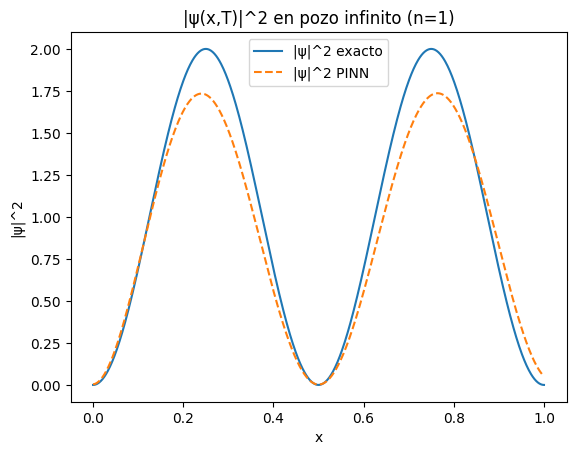

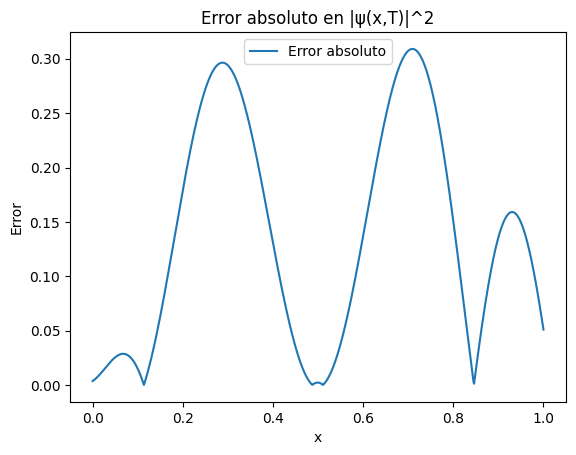

In [ ]:
with torch.no_grad():
    t_eval = torch.full((800, 1), T, device=DEVICE, dtype=DTYPE)
    x_eval = torch.linspace(0.0, L, 800, device=DEVICE, dtype=DTYPE).unsqueeze(1)

    psi_pred = model(torch.cat((t_eval, x_eval), dim=1))
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    mod2_pred = (psi_r_pred**2 + psi_i_pred**2).squeeze(1).cpu().numpy()

    psi_r_true, psi_i_true, En = exact_eigenstate(n_level, t_eval, x_eval, L=L, mass=mass, hbar=hbar)
    mod2_true = (psi_r_true**2 + psi_i_true**2).squeeze(1).cpu().numpy()

# Gráfico 1: |psi|^2 en t=T (PINN vs exacto)
plt.figure()
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_true, label="|ψ|^2 exacto")
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_pred, "--", label="|ψ|^2 PINN")
plt.title("|ψ(x,T)|^2 en pozo infinito (n=1)")
plt.xlabel("x")
plt.ylabel("|ψ|^2")
plt.legend()
plt.show()

# Gráfico 2: error absoluto en |psi|^2
plt.figure()
abs_err = np.abs(mod2_pred - mod2_true)
plt.plot(x_eval.squeeze(1).cpu().numpy(), abs_err, label="Error absoluto")
plt.title("Error absoluto en |ψ(x,T)|^2")
plt.xlabel("x")
plt.ylabel("Error")
plt.legend()
plt.show()


## Modelo Hibrido

### Definición del modelo

0. Llamado de modulos de interés

In [1]:
# Librerias de interés
import torch
import os
import sys

import pennylane as qml

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Global path
global_path = os.getcwd()

# Composición del path
global_path = global_path.split('/')

# Generación de path global al directorio padre 
relative_path = '/'.join(global_path[:-2])

# Linea adicional para ubicación de path en los scripts
sys.path.append(relative_path)

print(f"Se adiciona al $PATH la variable: {relative_path}")

Se adiciona al $PATH la variable: /Users/chubbs/Documents/UN/QCPINN


In [3]:
# Global path
global_path = os.getcwd()

# Linea adicional para ubicación de path en los scripts
sys.path.append(global_path)

from src.utils.plot_loss                import smooth_loss
from src.utils.logger                   import Logging
from src.nn.pde                         import schrodinger_operator
from src.utils.plot_prediction          import plt_prediction
from data.synthetic.schrodinger_dataset import exact_eigenstate
from src.nn.DVPDESolver                 import DVPDESolver
from src.nn.CVPDESolver                 import CVPDESolver
from src.nn.ClassicalSolver2            import ClassicalSolver2

import src.trainer.schrodinger_train as wave_train

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. Definición de Parametros de entrenamiento

In [4]:
mode = "hybrid"
num_qubits = 2
output_dim = 2
input_dim = 2
hidden_dim = 50
num_quantum_layers = 1
cutoff_dim = 5
classic_network = [input_dim, hidden_dim, output_dim]

# Input parameters: Iterable
L = 5.0        # dominio espacial [0, L]
T = 0.1        # tiempo final
hbar = 1.0
mass = 1.0
n_level = 0    # nivel (usaremos n=1)
omega  = 1.0
example = 'ho'
potential_fn = 0

if example.lower() != 'box':
    potential_fn = f"lambda t, x : 0.5 * {mass} * ({omega}**2) * (x**2)"

eq_params = {
    'example' : example,             # Ejemplo a correr: "BOX", "HO" 
    'L': L,                          # dominio espacial [0, L]
    'T' : T,                         # tiempo final
    'hbar' : hbar,                   # Atomic coordinates = 1
    'mass' : mass,                   # Atomic coordinates = 1
    'n_level' : n_level,             # nivel del pozo (usaremos n=1)
    'omega'   : omega,               # Natural frequency
    'potential_fn' : potential_fn,   # potential function
}

args = {
    "batch_size": 64,
    "epochs": 2000, 
    "lr": 1E-3,
    "seed": 42,
    "print_every": 1,
    "log_path": "./results/models/checkpoints/schrodinger/qho",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_qubits": num_qubits,
    "hidden_dim": hidden_dim,
    "num_quantum_layers": num_quantum_layers,
    "classic_network": classic_network,
    "q_ansatz": "sim_circ_13",  # options: "alternating_layer_tdcnot", "abbas" , farhi , sim_circ_13_half, sim_circ_13 , sim_circ_14_half, sim_circ_14 , sim_circ_15 ,sim_circ_19
    "mode": mode,
    "activation": "null",  # options: "null", "partial_measurement_half" , partial_measurement_x, tanh (Classical)
    "shots": 20,  # Analytical gradients enabled
    "problem": "schrodinger",
    "solver": "CV",  # options : "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,  # num_qubits >= cutoff_dim
    "class": "CVNeuralNetwork2",  # options CVNeuralNetwork1, CVNeuralNetwork2, CVNeuralNetwork3
    "encoding": None,  # options : "ampiltude" , "angle" for DV , none for others
    "eq_params" : eq_params,
    "noise" : False,
}


2. Validación de componentes

In [5]:
log_path = args["log_path"]
logger = Logging(log_path)

In [6]:
if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

model.logger.print(f"The settings used:")
for key, value in args.items():
    model.logger.print(f"{key} : {value}")

INFO:src.utils.logger:Using CVNeuralNetwork2 
INFO:src.utils.logger:Using CV Solver
INFO:src.utils.logger:The settings used:
INFO:src.utils.logger:batch_size : 64
INFO:src.utils.logger:epochs : 2000
INFO:src.utils.logger:lr : 0.001
INFO:src.utils.logger:seed : 42
INFO:src.utils.logger:print_every : 1
INFO:src.utils.logger:log_path : ./results/models/checkpoints/schrodinger/qho
INFO:src.utils.logger:input_dim : 2
INFO:src.utils.logger:output_dim : 2
INFO:src.utils.logger:num_qubits : 2
INFO:src.utils.logger:hidden_dim : 50
INFO:src.utils.logger:num_quantum_layers : 1
INFO:src.utils.logger:classic_network : [2, 50, 2]
INFO:src.utils.logger:q_ansatz : sim_circ_13
INFO:src.utils.logger:mode : hybrid
INFO:src.utils.logger:activation : null
INFO:src.utils.logger:shots : 20
INFO:src.utils.logger:problem : schrodinger
INFO:src.utils.logger:solver : CV
INFO:src.utils.logger:device : cpu
INFO:src.utils.logger:method : None
INFO:src.utils.logger:cutoff_dim : 5
INFO:src.utils.logger:class : CVNeur

In [7]:
# Definición de tipado para entrenamiento
DTYPE = torch.float32 
torch.set_default_dtype(DTYPE)
torch.manual_seed(0)

# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())
model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 520


### Entrenamiento del modelo

0. Entrenamiento con parametros por defecto

In [50]:
wave_train.train(model)

INFO:src.utils.logger:It: 1, Loss: 5.100e-01, Loss_res: 1.500e+01,  Loss_bcs: 3.565e-01, Loss_ut_ics: 3.503e-01, lr: 2.000e+04, Time: 1.07e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-21_17-35-16-978546/model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-21_17-35-16-978546/../model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 8.657e+10, Loss_res: 2.112e+12,  Loss_bcs: 6.480e+10, Loss_ut_ics: 6.480e+10, lr: 2.000e+04, Time: 1.20e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-21_17-35-16-978546/model.pth
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/schrodinger/qho/2025-09-21_17-35-16-978546/../model_weights.pth
INFO:src.utils.logger:It: 3, Loss: 8.099e+11, Loss_res: 1.327e+13,  Loss_bcs: 6.705e+11, Loss_ut_ics: 6.705e+11, lr: 2.000e+04, Time: 1.32e+00
INFO:src.utils.logger:Model state saved to ./resu

1. Métricas de entrenamiento

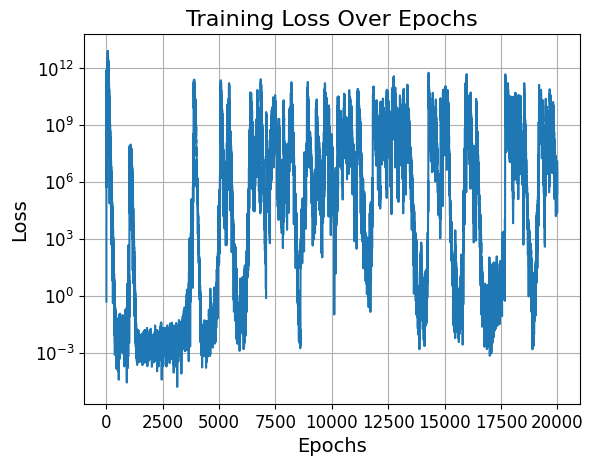

In [51]:
# Loss history plot 
plt.semilogy(range(len(model.loss_history)), model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

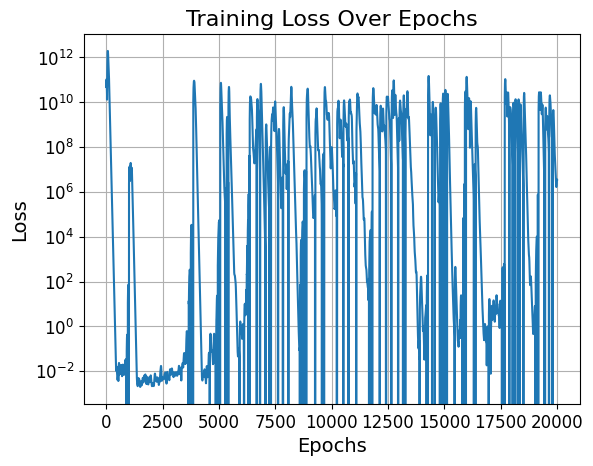

In [52]:
# Loss history plot 
plt.semilogy(range(len(model.loss_history)), smooth_loss(model.loss_history))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history_smooth.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

### Cargado de modelos

0. Cargado de parametros de modelos

In [16]:
# Generación de dirección
# - Original model trainining it's ./results/models/checkpoints/schrodinger/qho/2025-09-16_19-49-40-397660 : 33 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-16_23-56-29-184043 : 240 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-17_05-32-12-177643 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-18_23-15-25-067856 : 613 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_06-50-08-412171 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_12-51-35-995760 : 726 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_15-21-51-366423 : Partial eval

#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_08-02-15-211102 : 266 epochs
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_11-42-54-648031 : Partial eval
#                                - ./results/models/checkpoints/schrodinger/qho/2025-09-19_15-24-52-373878 : 1000 epochs

model_dir = "./../../results/models/checkpoints/schrodinger/qho/2025-09-22_05-12-29-898862"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model.pth")

# Load the state dictionary into the model
model.load_state(model_path)

# Set the model to evaluation mode (important for inference)
model.eval()

Model state loaded from ./../../results/models/checkpoints/schrodinger/qho/2025-09-22_05-12-29-898862/model.pth


/Users/chubbs/Documents/UN/QCPINN/src/nn/CVPDESolver.py:215: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


CVPDESolver(
  (quantum_layer): CVNeuralNetwork2(
    (activation): Tanh()
  )
  (preprocessor): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=2, bias=True)
  )
  (postprocessor): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=2, bias=True)
  )
  (loss_fn): MSELoss()
)

### Pruebas de predicción

0. Definición de parametros

In [17]:
# Parametros físicos del dominio
L       = model.args['eq_params']['L']          # dominio espacial [0, L]
T       = model.args['eq_params']['T']          # tiempo final
hbar    = model.args['eq_params']['hbar'] 
mass    = model.args['eq_params']['mass']
n_level = model.args['eq_params']['n_level']    # nivel del pozo (usaremos n=1)

example = model.args['eq_params']['example']

# Definición por defecto de parametros
potential_fn = 0; omega = 1.0

# Cargado según ejemplos de uso
if model.args['eq_params']['example'].lower() == 'ho':             # Oscilador armonico

    potential_fn = eval(model.args['eq_params']['potential_fn'])   # Función de potencial
    omega        = model.args['eq_params']['omega']                # Frecuencia natural

potential_fn = eval(model.args['eq_params']['potential_fn'])
omega = 1.0; example = 'ho'

1. Generación de datos

In [18]:
# settings
number_of_points = 50

# mesh of t - x evaluation
# - Create mesh grid with float32
if example.lower() == 'ho':
    t = np.linspace(0, T, number_of_points, dtype=np.float32)[:, None]
    x = np.linspace(-L, L, number_of_points, dtype=np.float32)[:, None]
else:
    t = np.linspace(0, T, number_of_points, dtype=np.float32)[:, None]
    x = torch.linspace(0.0, L, number_of_points, device=DEVICE, dtype=DTYPE).unsqueeze(1)

t, x = np.meshgrid(t, x);

t = t.flatten()[:, None]
x = x.flatten()[:, None]

# - Generation of torch elements
t_eval = torch.from_numpy(t); x_eval = torch.from_numpy(x)

# - Generation of input argument
X_star = (
    torch.hstack(
        (torch.from_numpy(t.flatten()[:, None]), torch.from_numpy(x.flatten()[:, None]))
    )
    .to(DEVICE)
    .to(torch.float32)
)

X = X_star.cpu().detach().numpy()

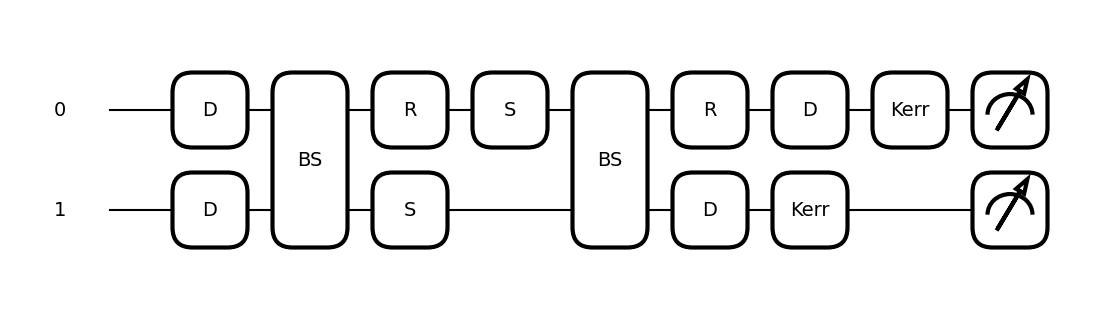

In [19]:
qml.draw_mpl(model.quantum_layer.circuit)(model.preprocessor(X_star[0, 0:2]));

In [20]:
# Predictions over values
with torch.no_grad():
    psi_pred = model(torch.cat((t_eval, x_eval), dim=1))
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    mod2_pred = (psi_r_pred**2 + psi_i_pred**2).squeeze(1).cpu().numpy()

    psi_r_true, psi_i_true, En = exact_eigenstate(n_level, t_eval, x_eval, L=L, mass=mass, hbar=hbar, omega=omega, example=example)
    mod2_true = (psi_r_true**2 + psi_i_true**2).squeeze(1).cpu().numpy()

2. Métricas de predicción

In [21]:
def magnitude_mean(y_pred_r, y_true_r, y_pred_i, y_true_i):

    # Squared differences for each value
    mse_r = (y_pred_r.cpu().detach().numpy() - y_true_r.cpu().detach().numpy())**2
    mse_i = (y_pred_i.cpu().detach().numpy() - y_true_i.cpu().detach().numpy())**2

    # Magnitude mse + norm
    mse = np.sqrt(mse_r + mse_i).mean()

    return mse

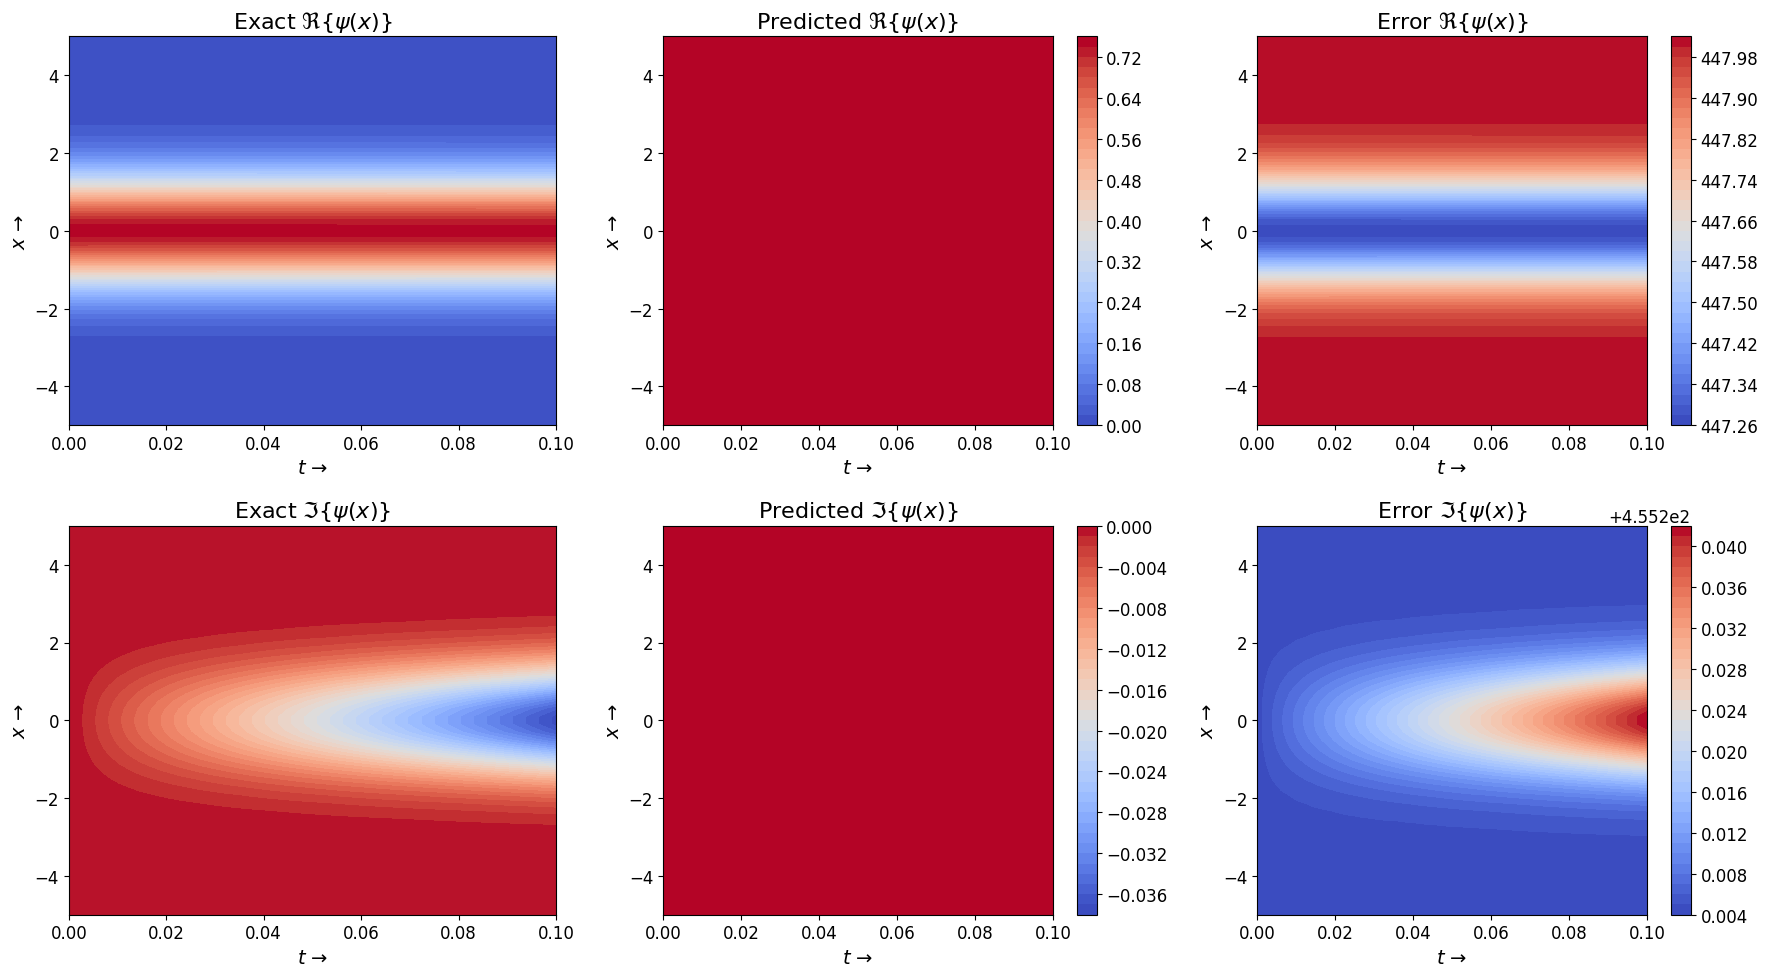

In [22]:
# Routine plots:
plt_prediction(
    logger,
    X,
    psi_r_true.cpu().detach().numpy(),
    psi_r_pred.cpu().detach().numpy(),
    psi_i_true.cpu().detach().numpy(),
    psi_i_pred.cpu().detach().numpy(),
)


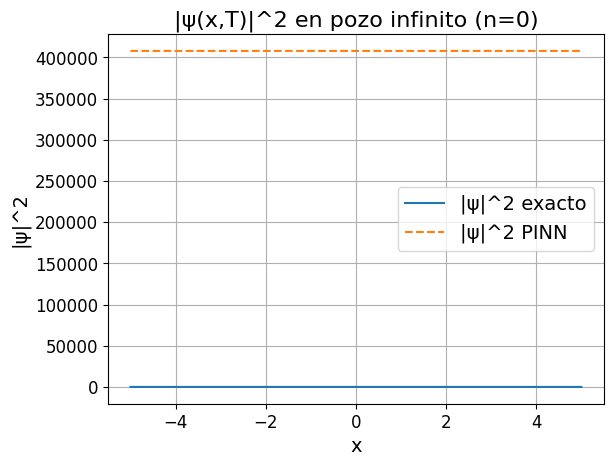

In [25]:
# Gráfico 1: |psi|^2 en t=T (PINN vs exacto)
plt.figure()
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_true, label="|ψ|^2 exacto")
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_pred, "--", label="|ψ|^2 PINN")
plt.title(f"|ψ(x,T)|^2 en pozo infinito (n={n_level})")
plt.xlabel("x")
plt.ylabel("|ψ|^2")
plt.legend()
plt.grid()

# Saving of solution comparison plot 
file_path = os.path.join(model.log_path, "solution_plot.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show(); plt.close("all")

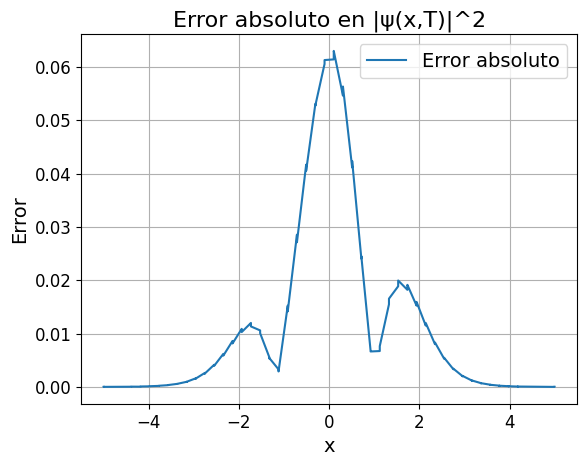

In [42]:
# Gráfico 2: error absoluto en |psi|^2
plt.figure()
abs_err = np.abs(mod2_pred - mod2_true)
plt.plot(x_eval.squeeze(1).cpu().numpy(), abs_err, label="Error absoluto")
plt.title("Error absoluto en |ψ(x,T)|^2")
plt.xlabel("x")
plt.ylabel("Error")
plt.legend()
plt.grid()

# Saving of solution comparison plot 
file_path = os.path.join(model.log_path, "error_plot.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show(); plt.close("all")